Columns: Index(['review', 'lowercased', 'urls_removed', 'html_removed',
       'emojis_removed', 'slangs_replaced', 'contractions_replaced',
       'punctuations_removed', 'numbers_removed', 'spelling_corrected',
       'stopwords_removed', 'stemmed_words', 'lemmatized', 'tokenized'],
      dtype='object')
                                              review  \
0  The product arrived on time. Packaging was gre...   
1           THIS PRODUCT IS JUST AMAZING! I LOVE IT.   
2  I bought this phone for $799, and it has a 120...   
3  Wow!!! This product is awesome... but a bit ex...   
4                The laptop works perfectly fine.      

                                          lowercased  \
0  the product arrived on time. packaging was gre...   
1           this product is just amazing! i love it.   
2  i bought this phone for $799, and it has a 120...   
3  wow!!! this product is awesome... but a bit ex...   
4                the laptop works perfectly fine.      

                  

/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


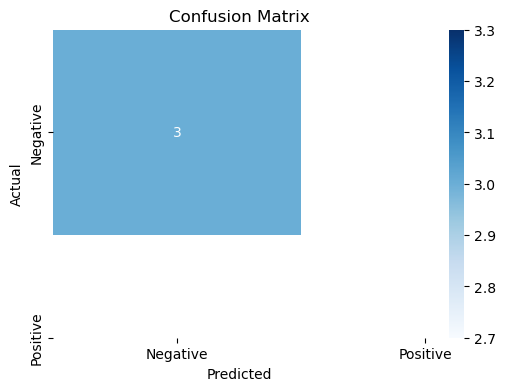

In [2]:
# ==========================================
# 1. Import Libraries
# ==========================================
import pandas as pd
import numpy as np

# NLP
from textblob import TextBlob

# ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 2. Load Dataset
# ==========================================
df = pd.read_csv("Processed_Reviews.csv")

# Clean column names
df.columns = df.columns.str.strip().str.lower()

print("Columns:", df.columns)
print(df.head())

# ==========================================
# 3. AUTo LABELING (Sentiment)
# ==========================================

def get_sentiment(text):
    polarity = TextBlob(str(text)).sentiment.polarity
    
    if polarity >= 0:
        return 1   # Positive
    else:
        return 0   # Negative

# Apply labeling using lemmatized column
df['label'] = df['lemmatized'].apply(get_sentiment)

print("\nLabel Distribution:")
print(df['label'].value_counts())

# ==========================================
# 4. Save New Labeled Dataset
# ==========================================
df.to_csv("Processed_Reviews_Labeled.csv", index=False)


# ==========================================
# 5. Prepare Data
# ==========================================
X = df['lemmatized']
y = df['label']

# ==========================================
# 6. TF-IDF Vectorization
# ==========================================
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(X)

# ==========================================
# 7. Train-Test Split
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)

# ==========================================
# 8. Model Training (Naïve Bayes)
# ==========================================
model = MultinomialNB()
model.fit(X_train, y_train)

# ==========================================
# 9. Prediction
# ==========================================
y_pred = model.predict(X_test)

# ==========================================
# 10. Evaluation
# ==========================================
print("\n===== MODEL PERFORMANCE =====")

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ==========================================
# 11. Confusion Matrix
# ==========================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()